---
title: Linear L1, L2 regularization and coeeficient significance
description: Эксперименты со значимостью коэффициентов и регуляризацией
date: "2025-03-06"
categories: [research]
---

In [69]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import (
    LinearRegression, 
    Ridge, 
    Lasso, 
)
from sklearn.datasets import make_regression
from tqdm import trange, tqdm
import plotly.express as px

# Контекст

На занятии по ML родилась занятная для исследования гипотеза - посмотреть оценки значимости коэффициентов которые обнуляет/стремится обнулить lasso и ridge соответственно, чтобы проверить часто ли они расходятся. 

Небольшой recap:

* Lasso - l1 - вводит штраф на сумму абсолютных значений весов, что делает лосс таким - $\frac{1}{2*n} * ||y - Xw||^2_2 + alpha * ||w||_1$. Обладает свойством отбора признаков, потому что может делать их веса равными нулю. 
* Ridge - l2 - вводит штраф на сумму квадратов, соответственно $||y - Xw||^2_2 + alpha * ||w||^2_2$. Веса не обнуляет, но может делать их очень маленькими. 

Базово считается, что в Lasso как бы встроен отбор фич, потому что если фиче присвоен вес 0, то в прогнозе она не участвует. Ridge насктолько явно признаки не отбирает, но один из подходов выбора признаков у линейных моделей - посмотреть на их значимость. Тогда, давайте говорить, что если коэффициент перед фичей у ridge не значим, то модель как бы "отобрала" признаки и сравним как часто отбор у lasso и ridge сходится. 


План по шагам: 

- Генерируем данные для регрессии 
- Бутстрапируем обучение Ridge, Lasso и обычной регрессий, чтобы получить оценки коэффициентов
- Повторяем шаги для разных параметров данных и разных параметров моделей 
- Смотрим как часто модели по-разному отбирают признаки 

# Код

In [44]:
def generate_data(
    samples, 
    features_total,
    features_informative, 
):
    
    # генерация красивых данных
    X, y, coeffs = make_regression(
                                    n_samples=samples, 
                                    n_features=features_total, 
                                    n_informative=features_informative, 
                                    n_targets=1, 
                                    coef=True, 
                                    bias=0, 
                                )

    # ухудшаем данные
    transformations = [
        lambda val: val + np.random.normal(size=len(val)), # Аддитивный шум
        lambda val: val * np.random.normal(size=len(val)), # Мультипликативный шум
        lambda val: np.log1p(np.abs(val)), # Модуль + Логарифмирование фичи
        np.exp, # Возведение в степень
        np.sin, # Берем синус
        lambda val: val, # пропускаем
    ]
    for idx in range(features_total):
        X[:, idx] = np.random.choice(transformations, size=1, p=(0.1, 0.1, 0.1, 0.1, 0.1, 0.5))[0](X[:, idx])
    
    return X, y, coeffs

def make_bootstrap(X, y, true_sig, alpha, iterations,):
    model_res = dict(base=[], ridge=[], lasso=[])
    for _ in range(iterations):
        # делаем подвыборки данных
        indixes = np.random.choice(np.arange(len(X)), len(X), replace=True)
        X_iter, y_iter = X[indixes], y[indixes]
        
        # Обучаемся
        base = LinearRegression().fit(X_iter, y_iter)
        ridge = Ridge(alpha=alpha).fit(X_iter, y_iter,)
        lasso = Lasso(alpha=alpha).fit(X_iter, y_iter,)
        
        # Сохраняем результаты
        model_res['base'].append(base.coef_)
        model_res['ridge'].append(ridge.coef_)
        model_res['lasso'].append(lasso.coef_)
        
    results = []
    for model in ['base', 'ridge', 'lasso']:
        lower, upper = np.percentile(np.array(model_res[model]), (0.025, 0.975), axis=0)
        model_sig = (upper * lower) > 0 # Интервал не содержит ноль в данном случае будем считать значимостью
        fp = ((model_sig == True) & (true_sig == False)).sum()  # False positive
        fn = ((model_sig == False) & (true_sig == True)).sum()  # False negative
        results.extend([fp, fn])   
    return results

# Моделирование

In [70]:
ALPHAS = [0.01, 0.1, 1, 10, 100]
FEATURES = [10, 25, 50,]
INFORMATIVE_SHARE = np.linspace(0.1, 1, 5)
SAMPLES = 1_000
BOOTSTRAP_ROUNDS = 100 
EXPERIMENT_ROUNDS = 100
total_iterations = EXPERIMENT_ROUNDS * len(INFORMATIVE_SHARE) * len(FEATURES) * len(ALPHAS) 

In [46]:
results = []

with tqdm(total=total_iterations) as pbar:
    for inf_share in INFORMATIVE_SHARE:
        for alpha in (ALPHAS):
            for features_num in FEATURES:
                for _ in range(EXPERIMENT_ROUNDS):
                    pass
                    # Генерируем данные для текущего эксперимента
                    features_num = int(features_num)
                    informative_features_num = int(features_num * inf_share)
                    X, y, coeffs = generate_data(SAMPLES, features_num, informative_features_num)
                    true_sig = coeffs != 0
                    
                    # Бутстреп
                    bootstrap_res = make_bootstrap(X, y, true_sig, alpha, BOOTSTRAP_ROUNDS)
                    
                    # Сохраняем параметры и результаты
                    results.append([features_num, informative_features_num, alpha] + bootstrap_res)
                    pbar.update(1)

100%|██████████| 7500/7500 [22:45<00:00,  5.49it/s]  


In [49]:
cols = ['features_num', 'informative_features_num', 'alpha', 'base_fp', 'base_fn', 'ridge_fp', 'ridge_fn', 'lasso_fp', 'lasso_fn']
results = pd.DataFrame(results, columns=cols)

In [68]:
prep_res = results.melt(id_vars=['features_num', 'informative_features_num', 'alpha'])
prep_res[['model', 'metric']] = prep_res['variable'].str.split('_', expand=True)
prep_res.to_excel('data/l1l2_res.xlsx')

# Результаты

* По значимости коэффициента нельзя делать вывод об отборе. Значимость у lasso почти не отличается от базовой модели, хотя некоторый отбор под капотом просиходит 
* Разные значения регуляризатора не меняют значимость оценок коэффициентов у lasso, но ожидаемо влияют на ridge (потому что он прямо в 0 сводит)



Параметры картинки: 

* 3 таблички с разными количеством фич - 10, 25, 50 
* Колонки: 
    * % informative features - доля фич, связанных с тарегтом (остальные просто шум)
    * Alpha - параметр регуляризации (влияет только на lasso и ridge)
* Строки: 
    * Разбивка по метрике: 
        * FNR - доля ложноотрицательных оценок - когда фича важна, но коэффицент в модели не значим 
        * FPR - доля ложноположительных оценок - когда фича не важна, но коэффициент в модели значим 
    * Разбивка по моделям
        * base - [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
        * lasso - [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
        * ridge - [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)


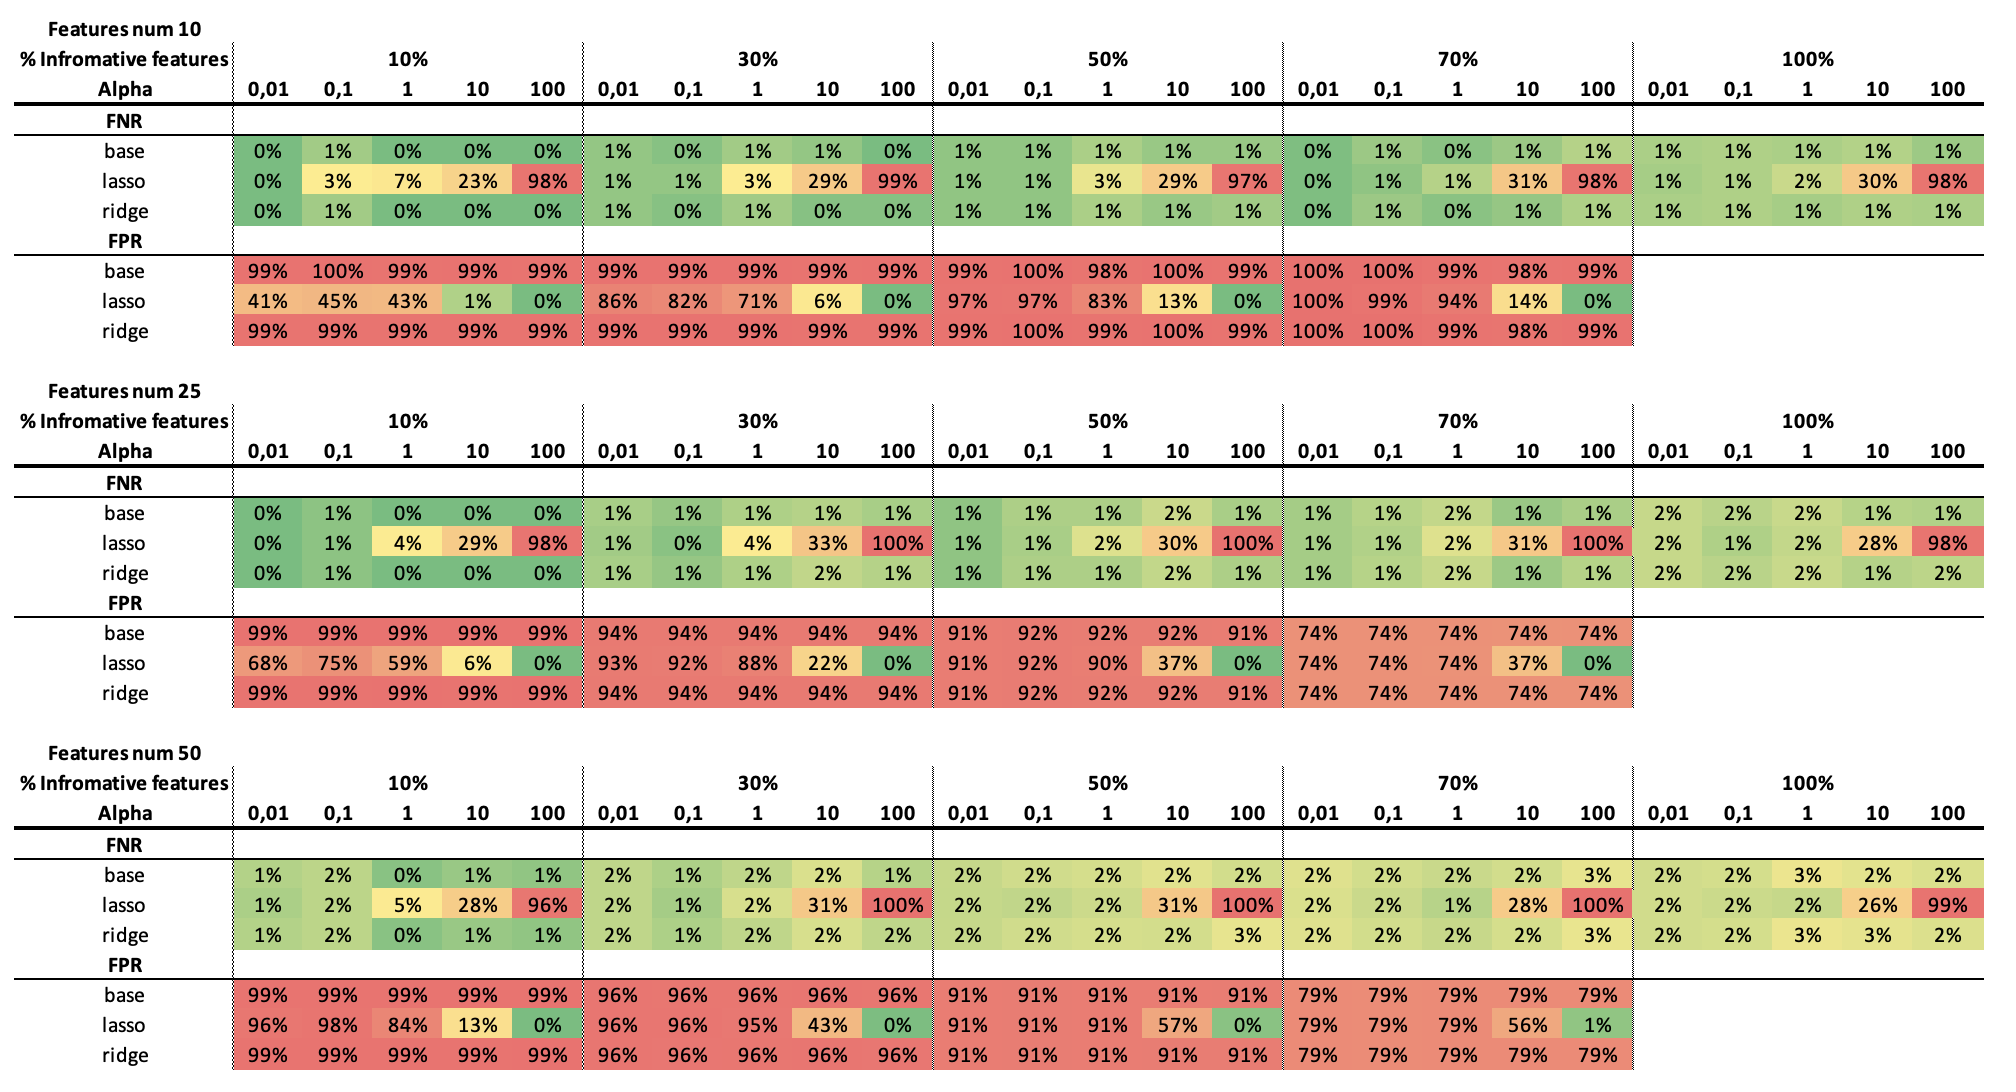